# Egg Gender Prediction Model - Training System
## Complete Machine Learning Pipeline

---

**System Features:**
- Load egg dataset from Google Drive
- Train multiple ML models (Random Forest, SVM, etc.)
- Evaluate model performance
- Save trained model for prediction
- Generate detailed performance reports

**Classification Rules:**
- ESI < 72: Male
- ESI 72-78: Female
- ESI > 78: Unhatched

## SECTION 1: Install and Import Dependencies

In [1]:
# Install required packages
%pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## SECTION 2: Mount Google Drive

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## SECTION 3: Configuration

In [4]:
# Dataset path in Google Drive
DATASET_PATH = '/content/drive/MyDrive/Egg Gender Prediction Model/Dataset/Egg_Dataset_Extended.xlsx'

# Model save path
MODEL_SAVE_PATH = '/content/drive/MyDrive/Egg Gender Prediction Model/'

# Model configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2

print('Configuration complete!')
print(f'Dataset path: {DATASET_PATH}')
print(f'Model will be saved to: {MODEL_SAVE_PATH}')

Configuration complete!
Dataset path: /content/drive/MyDrive/Egg Gender Prediction Model/Dataset/Egg_Dataset_Extended.xlsx
Model will be saved to: /content/drive/MyDrive/Egg Gender Prediction Model/


## SECTION 4: Load Dataset

In [5]:
print('Loading dataset from Google Drive...')
df = pd.read_excel(DATASET_PATH)

print('Dataset loaded successfully!')
print(f'\nDataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nFirst 5 rows:')
print(df.head())

print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

print('\nGender distribution:')
print(df['Gender'].value_counts())

Loading dataset from Google Drive...
Dataset loaded successfully!

Dataset shape: 1098 rows x 5 columns

First 5 rows:
   Egg Number  Width  Heigth  Shape Index(%)     Gender
0           2  40.52   54.06           74.95     Female
1           3  42.41   54.19           78.26  Unhatched
2           4  41.29   53.93           76.56     Female
3           5  37.16   54.40           68.30       Male
4           6  42.90   55.32           77.54     Female

Column names:
['Egg Number', 'Width', 'Heigth', 'Shape Index(%)', 'Gender']

Data types:
Egg Number          int64
Width             float64
Heigth            float64
Shape Index(%)    float64
Gender             object
dtype: object

Missing values:
Egg Number        0
Width             0
Heigth            0
Shape Index(%)    0
Gender            0
dtype: int64

Gender distribution:
Gender
Female       500
Male         400
Unhatched    198
Name: count, dtype: int64


## SECTION 5: Data Visualization

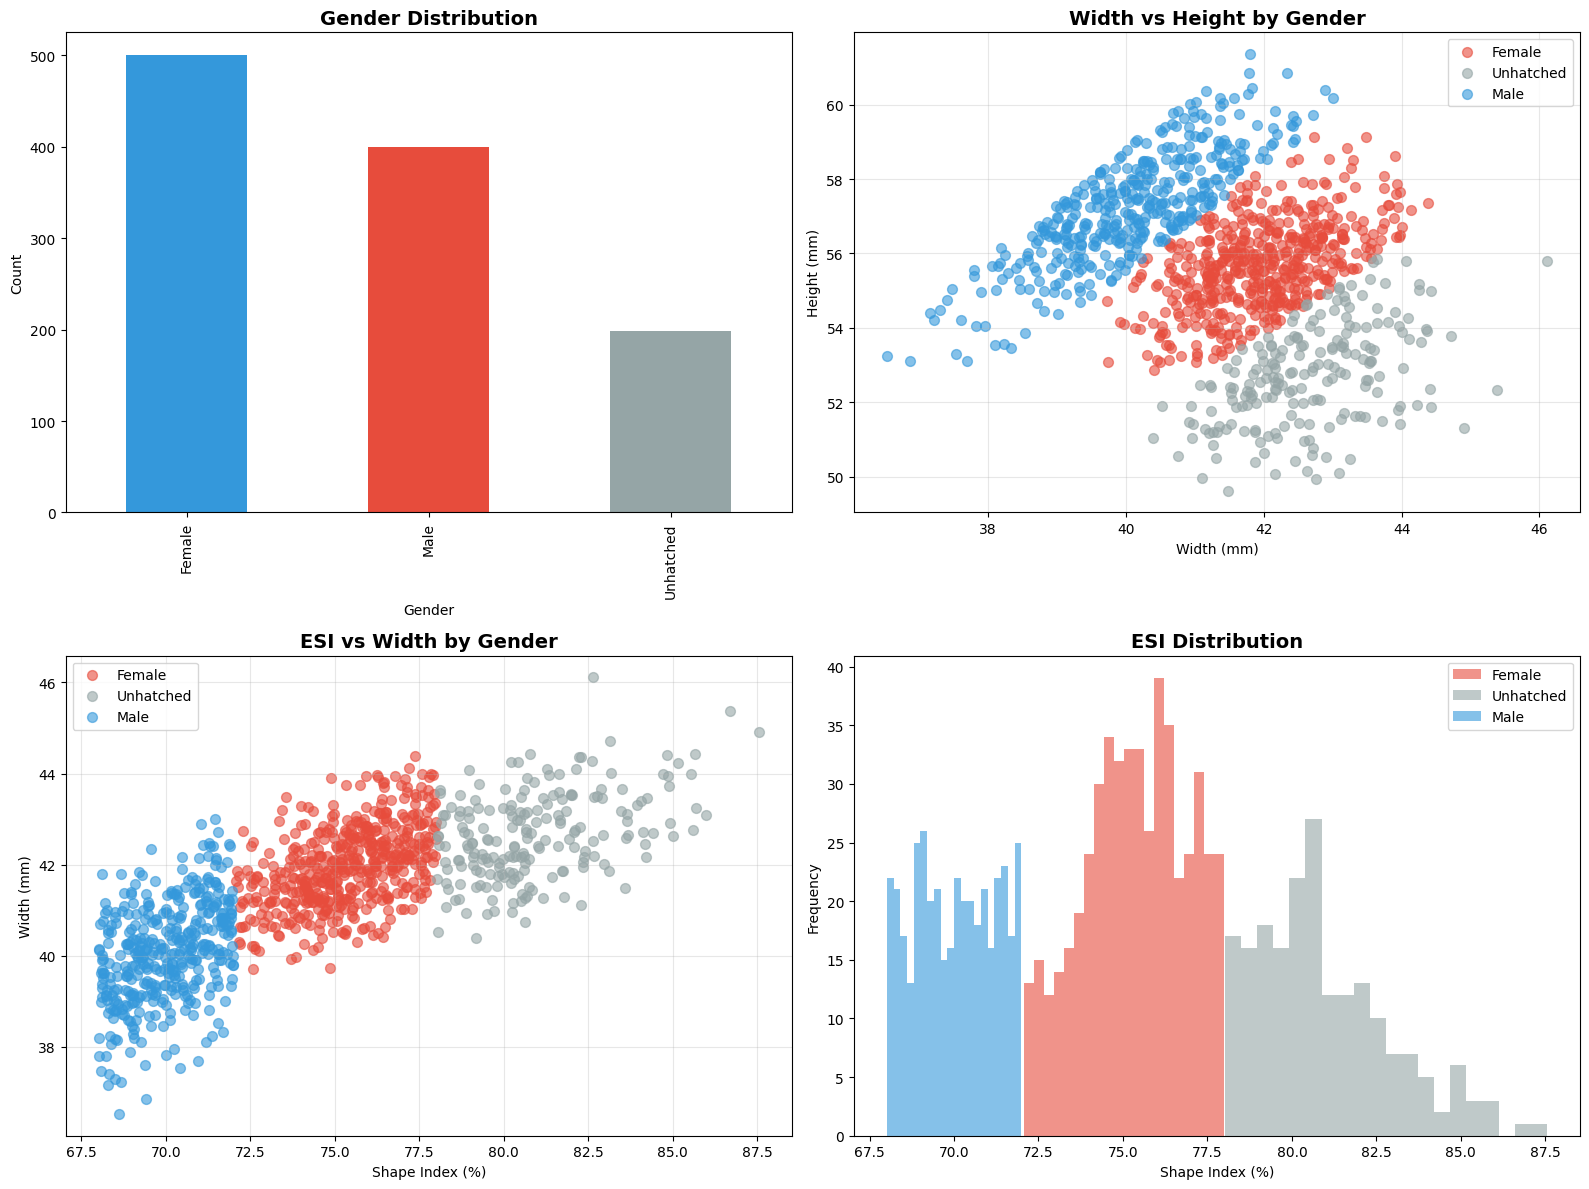

In [6]:
# Visualize gender distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart
df['Gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#95a5a6'])
axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')

# 2. Width vs Height scatter
colors_map = {'Male': '#3498db', 'Female': '#e74c3c', 'Unhatched': '#95a5a6'}
for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    axes[0, 1].scatter(subset['Width'], subset['Heigth'], label=gender, alpha=0.6, c=colors_map[gender], s=50)
axes[0, 1].set_xlabel('Width (mm)')
axes[0, 1].set_ylabel('Height (mm)')
axes[0, 1].set_title('Width vs Height by Gender', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ESI scatter
for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    axes[1, 0].scatter(subset['Shape Index(%)'], subset['Width'], label=gender, alpha=0.6, c=colors_map[gender], s=50)
axes[1, 0].set_xlabel('Shape Index (%)')
axes[1, 0].set_ylabel('Width (mm)')
axes[1, 0].set_title('ESI vs Width by Gender', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ESI histogram
for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    axes[1, 1].hist(subset['Shape Index(%)'], alpha=0.6, label=gender, bins=20, color=colors_map[gender])
axes[1, 1].set_xlabel('Shape Index (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('ESI Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## SECTION 6: Feature Engineering

In [7]:
# Create additional features
df['Aspect_Ratio'] = df['Width'] / df['Heigth']
df['Perimeter_Approx'] = 2 * (df['Width'] + df['Heigth'])
df['Area_Approx'] = df['Width'] * df['Heigth']
df['Width_Height_Diff'] = df['Width'] - df['Heigth']
df['Width_Height_Sum'] = df['Width'] + df['Heigth']

print('Feature engineering complete!')
print(f'Updated dataset shape: {df.shape}')

Feature engineering complete!
Updated dataset shape: (1098, 10)


## SECTION 7: Prepare Data for Training

In [8]:
# Select features
feature_columns = ['Width', 'Heigth', 'Shape Index(%)', 'Aspect_Ratio',
                   'Perimeter_Approx', 'Area_Approx', 'Width_Height_Diff']

X = df[feature_columns]
y = df['Gender']

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f'Target classes: {list(label_encoder.classes_)}')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Testing set: {len(X_test)} samples')
print('Data preparation complete!')

Target classes: ['Female', 'Male', 'Unhatched']
Training set: 878 samples
Testing set: 220 samples
Data preparation complete!


## SECTION 8: Train Multiple Models

In [9]:
print('Training models...\n')

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f'Accuracy: {accuracy*100:.2f}%')

# Select best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_accuracy = results[best_model_name]

print(f'\nBest Model: {best_model_name}')
print(f'Accuracy: {best_accuracy*100:.2f}%')

Training models...

Training Random Forest... Accuracy: 100.00%
Training Gradient Boosting... Accuracy: 100.00%
Training Decision Tree... Accuracy: 100.00%
Training SVM... Accuracy: 97.73%
Training KNN... Accuracy: 97.73%
Training Logistic Regression... Accuracy: 98.64%

Best Model: Random Forest
Accuracy: 100.00%


## SECTION 9: Model Evaluation

Classification Report:
              precision    recall  f1-score   support

      Female       1.00      1.00      1.00       100
        Male       1.00      1.00      1.00        80
   Unhatched       1.00      1.00      1.00        40

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



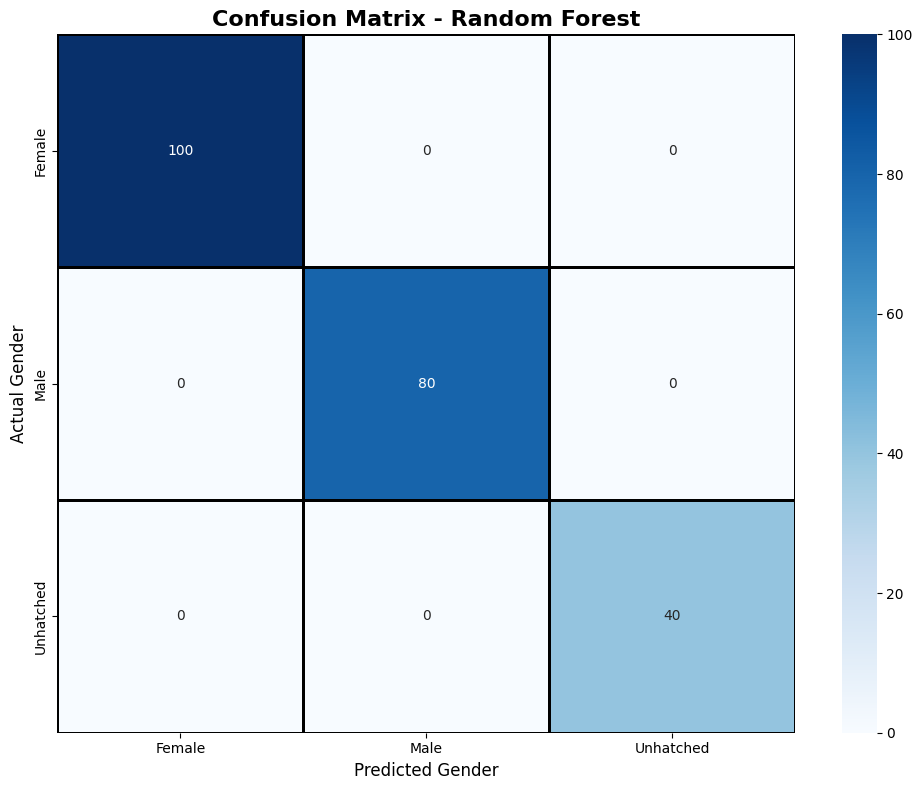

In [10]:
# Classification report
y_pred_best = best_model.predict(X_test_scaled)

print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            linewidths=2, linecolor='black')
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Gender', fontsize=12)
plt.xlabel('Predicted Gender', fontsize=12)
plt.tight_layout()
plt.show()

## SECTION 10: Feature Importance

Feature Importance:
             Feature  Importance
2     Shape Index(%)    0.316904
3       Aspect_Ratio    0.280853
6  Width_Height_Diff    0.259377
1             Heigth    0.083054
0              Width    0.037528
5        Area_Approx    0.011214
4   Perimeter_Approx    0.011070


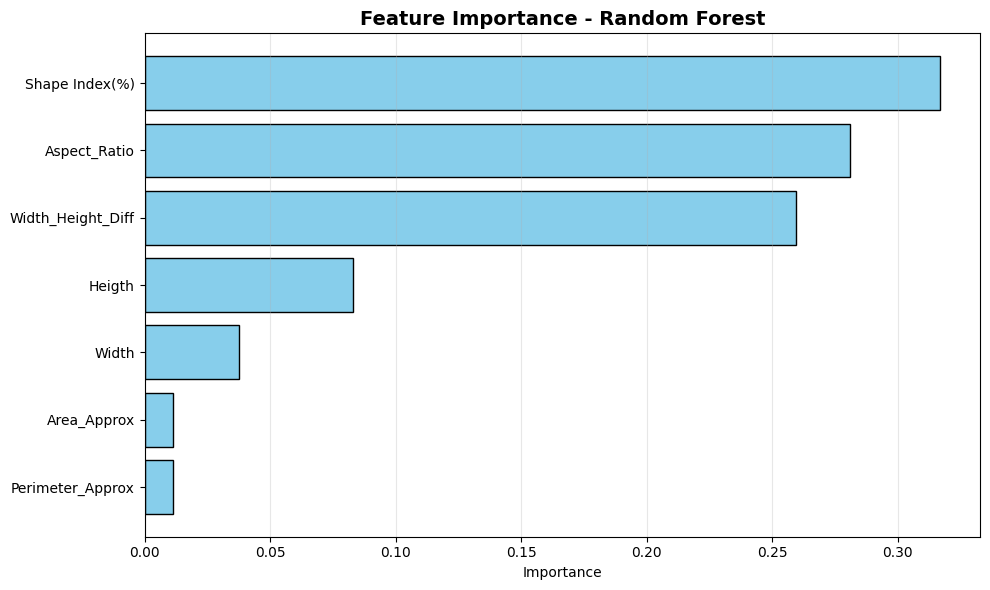

In [11]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print('Feature Importance:')
    print(feature_importance)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='black')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## SECTION 11: Save Model

In [12]:
# Save model files
joblib.dump(best_model, MODEL_SAVE_PATH + 'egg_gender_model.pkl')
joblib.dump(scaler, MODEL_SAVE_PATH + 'scaler.pkl')
joblib.dump(label_encoder, MODEL_SAVE_PATH + 'label_encoder.pkl')

print('Model saved successfully!')
print(f'Saved to: {MODEL_SAVE_PATH}')
print('\nFiles created:')
print('  1. egg_gender_model.pkl')
print('  2. scaler.pkl')
print('  3. label_encoder.pkl')

Model saved successfully!
Saved to: /content/drive/MyDrive/Egg Gender Prediction Model/

Files created:
  1. egg_gender_model.pkl
  2. scaler.pkl
  3. label_encoder.pkl


## SECTION 12: Test Predictions

In [13]:
# Sample predictions
sample_size = 10
sample_indices = np.random.choice(X_test.index, sample_size, replace=False)

print('Sample Predictions:\n')
correct = 0

for i, idx in enumerate(sample_indices, 1):
    sample_data = X.loc[[idx]]
    sample_scaled = scaler.transform(sample_data)
    prediction = best_model.predict(sample_scaled)
    pred_label = label_encoder.inverse_transform(prediction)[0]
    actual_label = y.loc[idx]

    is_correct = actual_label == pred_label
    if is_correct:
        correct += 1

    print(f'Sample {i}:')
    print(f'  Width: {sample_data["Width"].values[0]:.2f} mm')
    print(f'  Height: {sample_data["Heigth"].values[0]:.2f} mm')
    print(f'  ESI: {sample_data["Shape Index(%)"].values[0]:.2f}%')
    print(f'  Actual: {actual_label} | Predicted: {pred_label}')
    print(f'  {"CORRECT" if is_correct else "WRONG"}\n')

print(f'Sample Accuracy: {correct}/{sample_size} ({correct/sample_size*100:.1f}%)')

Sample Predictions:

Sample 1:
  Width: 41.13 mm
  Height: 57.54 mm
  ESI: 71.47%
  Actual: Male | Predicted: Male
  CORRECT

Sample 2:
  Width: 39.70 mm
  Height: 57.18 mm
  ESI: 69.43%
  Actual: Male | Predicted: Male
  CORRECT

Sample 3:
  Width: 41.28 mm
  Height: 54.97 mm
  ESI: 75.10%
  Actual: Female | Predicted: Female
  CORRECT

Sample 4:
  Width: 40.21 mm
  Height: 56.40 mm
  ESI: 71.28%
  Actual: Male | Predicted: Male
  CORRECT

Sample 5:
  Width: 37.54 mm
  Height: 53.30 mm
  ESI: 70.43%
  Actual: Male | Predicted: Male
  CORRECT

Sample 6:
  Width: 39.40 mm
  Height: 56.82 mm
  ESI: 69.34%
  Actual: Male | Predicted: Male
  CORRECT

Sample 7:
  Width: 43.21 mm
  Height: 58.83 mm
  ESI: 73.44%
  Actual: Female | Predicted: Female
  CORRECT

Sample 8:
  Width: 38.98 mm
  Height: 55.78 mm
  ESI: 69.88%
  Actual: Male | Predicted: Male
  CORRECT

Sample 9:
  Width: 41.27 mm
  Height: 50.85 mm
  ESI: 81.15%
  Actual: Unhatched | Predicted: Unhatched
  CORRECT

Sample 10:
  Wid

## SECTION 13: Summary Report

In [14]:
print('=' * 60)
print('TRAINING SUMMARY REPORT')
print('=' * 60)

print(f'\nDataset Statistics:')
print(f'  Total samples: {len(df)}')
print(f'  Training samples: {len(X_train)}')
print(f'  Testing samples: {len(X_test)}')
print(f'  Features used: {len(feature_columns)}')

print(f'\nBest Model: {best_model_name}')
print(f'  Training Accuracy: {best_model.score(X_train_scaled, y_train)*100:.2f}%')
print(f'  Testing Accuracy: {best_accuracy*100:.2f}%')

print(f'\nSaved Files:')
print(f'  1. egg_gender_model.pkl')
print(f'  2. scaler.pkl')
print(f'  3. label_encoder.pkl')

print(f'\nTraining Complete!')
print(f'Your model is ready for egg gender prediction!')
print('=' * 60)

TRAINING SUMMARY REPORT

Dataset Statistics:
  Total samples: 1098
  Training samples: 878
  Testing samples: 220
  Features used: 7

Best Model: Random Forest
  Training Accuracy: 100.00%
  Testing Accuracy: 100.00%

Saved Files:
  1. egg_gender_model.pkl
  2. scaler.pkl
  3. label_encoder.pkl

Training Complete!
Your model is ready for egg gender prediction!
